In [23]:
import kagglehub
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt

### Download English writing dataset

In [24]:

# Download latest version
path_english = kagglehub.dataset_download("tejasreddy/iam-handwriting-top50")

print("Path to dataset files:", path_english)

Path to dataset files: C:\Users\Liam\.cache\kagglehub\datasets\tejasreddy\iam-handwriting-top50\versions\2


### Download Arabic writing dataset

In [25]:
# Download latest version
path_arabic = kagglehub.dataset_download("humansintheloop/arabic-documents-ocr-dataset")

print("Path to dataset files:", path_arabic)

Path to dataset files: C:\Users\Liam\.cache\kagglehub\datasets\humansintheloop\arabic-documents-ocr-dataset\versions\1


### Download Cyrillic writing dataset

In [26]:
path_cyrillic = kagglehub.dataset_download("constantinwerner/cyrillic-handwriting-dataset")
print("Path to dataset files:", path_cyrillic)

Path to dataset files: C:\Users\Liam\.cache\kagglehub\datasets\constantinwerner\cyrillic-handwriting-dataset\versions\5


You have to make sure the path goes directly to the folder with the images in it. The arabic datset has a bunch of other folders without hand writing so you have to change the paths to be correct below.

### Load in Data

In [27]:
path_arabic = f'{path_arabic}/Documents/Documents/Handwritten text/img'

path_english = f"{path_english}/data_subset/data_subset"

path_cyrillic_train = f"{path_cyrillic}/train"

path_cyrillic_test = f"{path_cyrillic}/test"

In [28]:
def load_images_from_folder(folder_path, language_label, max_images=None, target_size=(128, 128)):
    """
    Load images from a folder and convert them to numpy arrays.
    
    Parameters:
    - folder_path: Path to the folder containing images
    - language_label: Label for the language (e.g., 'arabic' or 'english')
    - max_images: Maximum number of images to load (None for all)
    - target_size: Tuple of (width, height) to resize images to
    
    Returns:
    - List of tuples (image_array, label)
    """
    images_data = []
    valid_extensions = {'.jpg', '.png'}
    
    # Get all image files
    image_files = [f for f in os.listdir(folder_path) 
                   if os.path.splitext(f.lower())[1] in valid_extensions]
    
    if max_images:
        image_files = image_files[:max_images]
    
    for filename in image_files:
        # Load image
        img_path = os.path.join(folder_path, filename)
        img = Image.open(img_path)
            
        # Convert to grayscale
        img = img.convert('L')
            
        # Resize to target size
        img = img.resize(target_size)
            
        # Convert to numpy array
        img_array = np.array(img)
            
        # Flatten to 1D array
        img_flat = img_array.flatten()
            
        images_data.append((img_flat, language_label))
    
    return images_data

def create_dataframe(english_folder, 
                     cyrillic_folders, 
                     num_samples_per_language=None, 
                     target_size=(128, 128),
                     test_size=0.2,
                     random_state=42):
    """
    Create train and test DataFrames with equal number of images from each language.
    
    Parameters:
    - english_folder: Path to folder with English images
    - cyrillic_folder: Path to folder with Cyrillic images
    - num_samples_per_language: Number of samples to take from each language
    - target_size: Tuple of (width, height) to resize images to
    - test_size: Proportion of data to use for testing (default 0.2 = 20%)
    - random_state: Random seed for reproducibility
    
    Returns:
    - Tuple of (train_df, test_df)
    """
    
    # Load English images
    print("Loading English images...")
    english_data = load_images_from_folder(
        english_folder, 
        'english', 
        max_images=num_samples_per_language,
        target_size=target_size
    )

    # NEEEDS HEEEEEEELP
    print("Loading Cyrillic images...")
    cyrillic_data = []
    for folder in cyrillic_folders:
        print(f"  Loading from {folder}...")
        folder_data = load_images_from_folder(
            folder, 
            'cyrillic', 
            max_images=num_samples_per_language, 
            target_size=target_size
        )
        cyrillic_data.extend(folder_data)
    
    # Ensure equal number of samples
    min_samples = min(len(english_data), len(cyrillic_data))
    english_data = english_data[:min_samples]
    cyrillic_data = cyrillic_data[:min_samples]
    
    print(f"Using {min_samples} images from each language")
    
    # Combine data
    all_data = english_data + cyrillic_data
    
    # Create DataFrame
    df = pd.DataFrame(all_data, columns=['image', 'language'])
    
    # Split into train and test sets with stratification to maintain class balance
    train_df, test_df = train_test_split(
        df, 
        test_size=test_size, 
        random_state=random_state,
        stratify=df['language']  # Ensures equal proportion of each language in both sets
    )
    
    # Reset indices
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    
    return train_df, test_df

if __name__ == "__main__":
    train_df, test_df = create_dataframe(
        english_folder=path_english,
        cyrillic_folders=[path_cyrillic_train, path_cyrillic_test],
        num_samples_per_language=500,
        test_size=0.2  # 80% train, 20% test
    )
    
    print(f"\nTraining set shape: {train_df.shape}")
    print(f"Test set shape: {test_df.shape}")
    
    print(f"\nTraining language distribution:\n{train_df['language'].value_counts()}")
    print(f"\nTest language distribution:\n{test_df['language'].value_counts()}")
    
    print(f"\nFirst few rows of training data:")
    print(train_df.head())

Loading English images...
Loading Cyrillic images...
  Loading from C:\Users\Liam\.cache\kagglehub\datasets\constantinwerner\cyrillic-handwriting-dataset\versions\5/train...
  Loading from C:\Users\Liam\.cache\kagglehub\datasets\constantinwerner\cyrillic-handwriting-dataset\versions\5/test...
Using 500 images from each language

Training set shape: (800, 2)
Test set shape: (200, 2)

Training language distribution:
language
english     400
cyrillic    400
Name: count, dtype: int64

Test language distribution:
language
english     100
cyrillic    100
Name: count, dtype: int64

First few rows of training data:
                                               image  language
0  [255, 255, 255, 255, 255, 255, 255, 255, 255, ...   english
1  [17, 15, 23, 16, 10, 10, 18, 33, 30, 26, 36, 3...  cyrillic
2  [255, 255, 255, 255, 255, 255, 255, 255, 255, ...   english
3  [178, 179, 179, 179, 180, 181, 178, 174, 172, ...  cyrillic
4  [255, 255, 255, 255, 255, 255, 255, 255, 255, ...   english


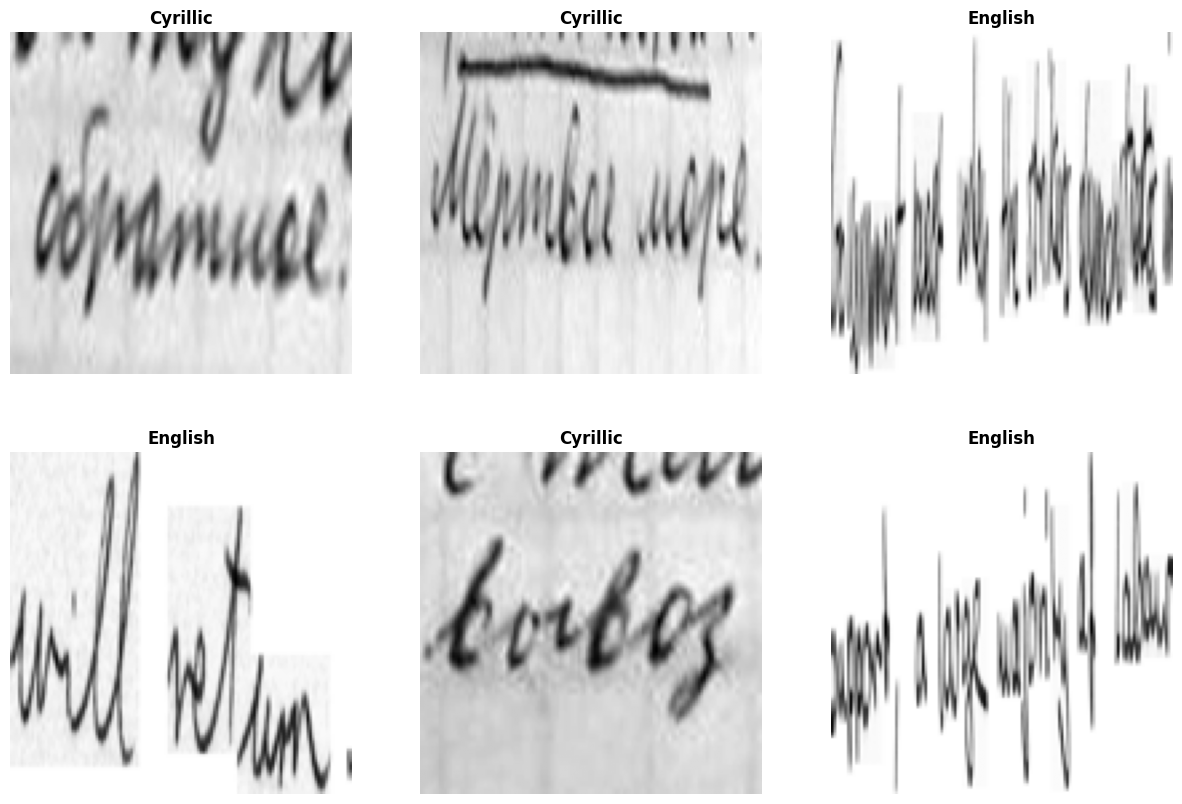

In [29]:
def visualize_sample_images(df, num_samples=6, img_height=128, img_width=128):
    """
    Visualize multiple random images from the dataset.
    
    Parameters:
    - df: DataFrame with 'image' and 'language' columns
    - num_samples: Number of images to display
    - img_height: Height of the image
    - img_width: Width of the image
    """
    
    sample_df = df.sample(n=min(num_samples, len(df)), random_state=42)
    
    rows = (num_samples + 2) // 3 
    cols = min(3, num_samples)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    
    if num_samples == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if num_samples > 3 else axes
    
    for idx, (_, row) in enumerate(sample_df.iterrows()):
        if idx >= num_samples:
            break
            
        img_2d = row['image'].reshape(img_height, img_width)
        
        axes[idx].imshow(img_2d, cmap='gray')
        axes[idx].set_title(f"{row['language'].capitalize()}", fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    plt.show()

visualize_sample_images(train_df, num_samples=6, img_height=128, img_width=128)

In [30]:
# exploded data for cnn
df_explode = pd.concat([pd.DataFrame(df['image'].to_list()), df['language']], axis=1)
df_explode.to_csv("data.csv", index=False)

NameError: name 'df' is not defined

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ipythonx/msratd500")

print("Path to dataset files:", path)

Path to dataset files: /Users/sasha/.cache/kagglehub/datasets/ipythonx/msratd500/versions/1
